# 00 — Configuración, fuentes observacionales y trayectoria termodinámica

Este notebook prepara las carpetas de salida, define los datos observacionales que se usarán como comparación y construye las tablas de condiciones termodinámicas.

El objetivo es dejar ficheros CSV reutilizables por los notebooks de simulación y por la memoria en Typst.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scienceplots
    plt.style.use(["science", "grid"])
except Exception as exc:
    print("scienceplots no disponible, usando estilo por defecto:", exc)

BASE = Path.cwd()
FIG_DIR = BASE / "figures"
TAB_DIR = BASE / "tables"
DATA_DIR = BASE / "data"
GIF_DIR = BASE / "gifs"
for d in [FIG_DIR, TAB_DIR, DATA_DIR, GIF_DIR]:
    d.mkdir(exist_ok=True)

print("Base:", BASE)

Base: /home/daniel/GitHub/BNN_simulation/main


## Datos observacionales de referencia

No hay una “medida experimental de laboratorio” de las abundancias primordiales: se infieren de observaciones astrofísicas y de modelos de evolución química. Para comparar con una red BBN básica se usan normalmente:

- D/H en sistemas de absorción de cuásares de muy baja metalicidad.
- La fracción másica primordial de helio, $Y_p \simeq X(^4\mathrm{He})$, de regiones H II pobres en metales.
- El litio del plateau de Spite en estrellas pobres en metales.
- $^3\mathrm{He}/\mathrm{H}$, que es bastante menos limpio observacionalmente.

Estas cifras son valores de referencia razonables, no una compilación exhaustiva.

In [2]:
# Valores de referencia para comparación gráfica.
# value y sigma están en unidades lineales.
# Para Li se compara normalmente Li7/H observado con (Li7 + Be7)/H predicho,
# porque Be7 captura electrones y acaba contribuyendo a Li7 en épocas posteriores.

obs = pd.DataFrame([
    {
        "observable": "D/H",
        "quantity": "number_ratio",
        "value": 2.527e-5,
        "sigma": 0.030e-5,
        "model_column": "D/H",
        "source_key": "Cooke2018",
        "note": "Primordial deuterium from metal-poor quasar absorption systems."
    },
    {
        "observable": "Yp_He4",
        "quantity": "mass_fraction",
        "value": 0.2462,
        "sigma": 0.0022,
        "model_column": "X_He4",
        "source_key": "Aver2021",
        "note": "Primordial helium mass fraction from metal-poor HII regions."
    },
    {
        "observable": "He3/H",
        "quantity": "number_ratio",
        "value": 1.1e-5,
        "sigma": 0.2e-5,
        "model_column": "He3/H",
        "source_key": "Steigman2010",
        "note": "Poor primordial determination; Galactic HII values, mostly a consistency check."
    },
    {
        "observable": "Li7/H",
        "quantity": "number_ratio",
        "value": 1.6e-10,
        "sigma": 0.3e-10,
        "model_column": "Li7_plus_Be7_over_H",
        "source_key": "FieldsLithiumReview",
        "note": "Observed Spite plateau scale; compare to predicted Li7+Be7."
    },
])
obs.to_csv(DATA_DIR / "observational_abundances.csv", index=False)
obs

,observable,quantity,value,sigma,model_column,source_key,note
0,D/H,number_ratio,2.527000e-05,3.000000e-07,D/H,Cooke2018,Primordial deuterium from metal-poor quasar ab...
1,Yp_He4,mass_fraction,2.462000e-01,2.200000e-03,X_He4,Aver2021,Primordial helium mass fraction from metal-poo...
2,He3/H,number_ratio,1.100000e-05,2.000000e-06,He3/H,Steigman2010,Poor primordial determination; Galactic HII va...
3,Li7/H,number_ratio,1.600000e-10,3.000000e-11,Li7_plus_Be7_over_H,FieldsLithiumReview,Observed Spite plateau scale; compare to predi...


## Condiciones del enunciado y trayectoria termodinámica usada

El trabajo pide tres snapshots:

- $t\sim 50\,\mathrm{s}$, $T_9=1.7$, $
ho=2	imes10^{-4}\,\mathrm{g\,cm^{-3}}$;
- $t\sim 200\,\mathrm{s}$, $T_9=1.0$, $
ho=2	imes10^{-5}\,\mathrm{g\,cm^{-3}}$;
- $t\sim 1000\,\mathrm{s}$, $T_9=0.4$, $
ho=2	imes10^{-6}\,\mathrm{g\,cm^{-3}}$.

La simulación principal se arranca directamente en el primer snapshot, $t_0=50\,\mathrm{s}$, con la razón inicial $n/p=1/7$ indicada en el enunciado. Por tanto, no se incluye ningún arranque artificial a tiempos anteriores en las gráficas principales.

In [3]:
# Snapshots del enunciado
snapshots = pd.DataFrame({
    "label": ["50 s", "200 s", "1000 s"],
    "t_s": [50.0, 200.0, 1000.0],
    "T9": [1.7, 1.0, 0.4],
    "rho_g_cm3": [2.0e-4, 2.0e-5, 2.0e-6],
})
snapshots["T_K"] = snapshots["T9"] * 1.0e9
snapshots.to_csv(DATA_DIR / "bbn_assignment_snapshots.csv", index=False)
snapshots

,label,t_s,T9,rho_g_cm3,T_K
0,50 s,50.0,1.7,0.000200,1.700000e+09
1,200 s,200.0,1.0,0.000020,1.000000e+09
2,1000 s,1000.0,0.4,0.000002,4.000000e+08


In [4]:
# Trayectoria termodinámica forzada.
#
# En lugar de una interpolación log-lineal por tramos, usamos thermo_model.py:
#   1) referencia física de universo dominado por radiación, T9 ~ t^{-1/2};
#   2) densidad bariónica de referencia rho_b = m_u eta n_gamma(T);
#   3) corrección suave PCHIP en log-log para pasar EXACTAMENTE por los snapshots.

from thermo_model import make_thermo_functions, ETA10_PLANCK_APPROX

thermo_model = make_thermo_functions(snapshots, eta10_ref=ETA10_PLANCK_APPROX)

T9_of_t = thermo_model.T9_of_t
T_of_t = thermo_model.T_of_t
rho_of_t = thermo_model.rho_of_t
eta_of_t = thermo_model.eta_of_t
n_gamma_cm3 = thermo_model.n_gamma_cm3

# Tabla termo para los tiempos relevantes del ejercicio.
t_grid_table = np.array([50.0, 100.0, 200.0, 500.0, 1000.0])
thermo = pd.DataFrame({
    "t_s": t_grid_table,
    "T9_forced": T9_of_t(t_grid_table),
    "T_K_forced": T_of_t(t_grid_table),
    "rho_forced_g_cm3": rho_of_t(t_grid_table),
    "eta_effective": eta_of_t(t_grid_table),
    "eta10_effective": 1.0e10 * eta_of_t(t_grid_table),
    "T9_radiation_reference": thermo_model.T9_radiation_base(t_grid_table),
    "T9_correction": thermo_model.T_correction_of_t(t_grid_table),
    "rho_eta_reference_g_cm3": thermo_model.rho_eta_reference_of_t(t_grid_table),
    "rho_correction": thermo_model.rho_correction_of_t(t_grid_table),
    "n_gamma_cm3": n_gamma_cm3(T_of_t(t_grid_table)),
})

# Nombre nuevo usado por la memoria.
thermo.to_csv(DATA_DIR / "bbn_thermo_curve_forced.csv", index=False)

# Nombre antiguo mantenido para compatibilidad con notebooks previos.
thermo_legacy = thermo.rename(columns={
    "T9_forced": "T9_assignment_interp",
    "T_K_forced": "T_K_assignment_interp",
    "rho_forced_g_cm3": "rho_g_cm3_assignment_interp",
    "eta_effective": "eta",
    "eta10_effective": "eta10",
})
thermo_legacy.to_csv(DATA_DIR / "thermodynamic_history_reference.csv", index=False)

# Comprobación exacta de los snapshots del enunciado.
t_check = snapshots["t_s"].to_numpy(float)
T9_model = T9_of_t(t_check)
rho_model = rho_of_t(t_check)
thermo_check = pd.DataFrame({
    "label": snapshots["label"],
    "t_s": t_check,
    "T9_assignment": snapshots["T9"].to_numpy(float),
    "T9_model": T9_model,
    "rel_error_T9": (T9_model - snapshots["T9"].to_numpy(float)) / snapshots["T9"].to_numpy(float),
    "rho_assignment_g_cm3": snapshots["rho_g_cm3"].to_numpy(float),
    "rho_model_g_cm3": rho_model,
    "rel_error_rho": (rho_model - snapshots["rho_g_cm3"].to_numpy(float)) / snapshots["rho_g_cm3"].to_numpy(float),
    "eta10_effective": 1.0e10 * eta_of_t(t_check),
    "T9_radiation_reference": thermo_model.T9_radiation_base(t_check),
    "rho_eta_reference_g_cm3": thermo_model.rho_eta_reference_of_t(t_check),
})
thermo_check.to_csv(DATA_DIR / "bbn_thermo_snapshot_check.csv", index=False)

print("CSV escritos:")
print("  ", DATA_DIR / "bbn_thermo_curve_forced.csv")
print("  ", DATA_DIR / "bbn_thermo_snapshot_check.csv")
print("  ", DATA_DIR / "thermodynamic_history_reference.csv")
thermo_check

CSV escritos:
   /home/daniel/GitHub/BNN_simulation/main/data/bbn_thermo_curve_forced.csv
   /home/daniel/GitHub/BNN_simulation/main/data/bbn_thermo_snapshot_check.csv
   /home/daniel/GitHub/BNN_simulation/main/data/thermodynamic_history_reference.csv


,label,t_s,T9_assignment,T9_model,rel_error_T9,rho_assignment_g_cm3,rho_model_g_cm3,rel_error_rho,eta10_effective,T9_radiation_reference,rho_eta_reference_g_cm3
0,50 s,50.0,1.7,1.7,0.0,0.000200,0.000200,0.0,12.088327,2.000000,0.000101
1,200 s,200.0,1.0,1.0,0.0,0.000020,0.000020,0.0,5.938995,1.000000,0.000021
2,1000 s,1000.0,0.4,0.4,0.0,0.000002,0.000002,0.0,9.279679,0.447214,0.000001


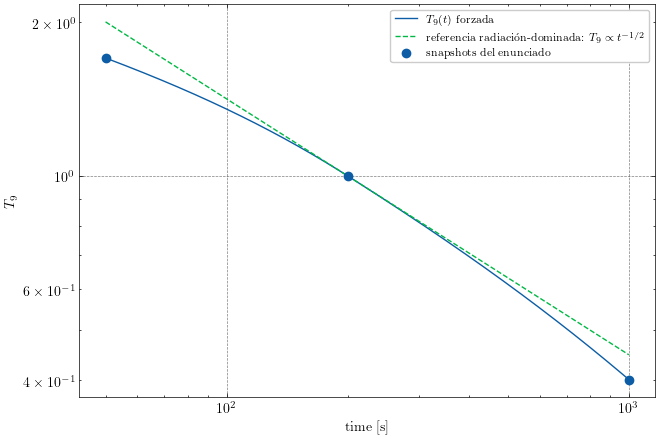

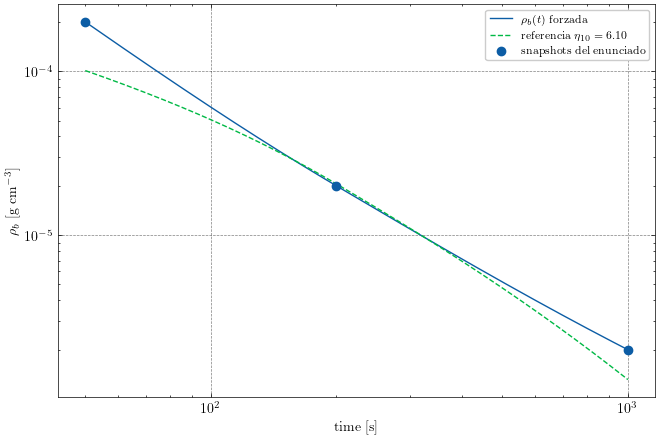

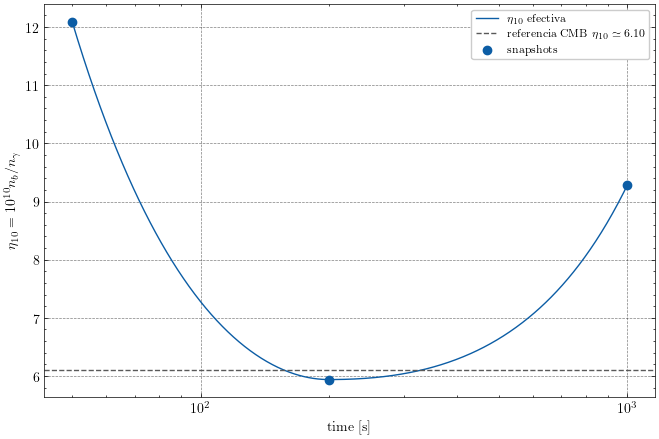

In [5]:
# Gráficas de la historia termodinámica usada en las simulaciones.
# Se guardan con los nombres que llama directamente la memoria Typst.

t_plot = np.geomspace(50.0, 1000.0, 600)

fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.loglog(t_plot, T9_of_t(t_plot), label=r"$T_9(t)$ forzada")
ax.loglog(t_plot, thermo_model.T9_radiation_base(t_plot), "--", label=r"referencia radiación-dominada: $T_9\propto t^{-1/2}$")
ax.scatter(snapshots["t_s"], snapshots["T9"], marker="o", zorder=5, label="snapshots del enunciado")
ax.set_xlabel("time [s]")
ax.set_ylabel(r"$T_9$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_thermo_T9_forced_radiation.pdf")
# Compatibilidad con nombres anteriores.
fig.savefig(FIG_DIR / "fig_thermo_T9_models.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.loglog(t_plot, rho_of_t(t_plot), label=r"$\rho_b(t)$ forzada")
ax.loglog(t_plot, thermo_model.rho_eta_reference_of_t(t_plot), "--", label=rf"referencia $\eta_{{10}}={ETA10_PLANCK_APPROX:.2f}$")
ax.scatter(snapshots["t_s"], snapshots["rho_g_cm3"], marker="o", zorder=5, label="snapshots del enunciado")
ax.set_xlabel("time [s]")
ax.set_ylabel(r"$\rho_b$ [g cm$^{-3}$]")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_thermo_rho_forced_eta.pdf")
# Compatibilidad con nombres anteriores.
fig.savefig(FIG_DIR / "fig_thermo_rho_model.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(6.8, 4.6))
eta10_plot = 1.0e10 * eta_of_t(t_plot)
ax.semilogx(t_plot, eta10_plot, label=r"$\eta_{10}$ efectiva")
ax.axhline(ETA10_PLANCK_APPROX, ls="--", color="0.35", label=rf"referencia CMB $\eta_{{10}}\simeq {ETA10_PLANCK_APPROX:.2f}$")
ax.scatter(snapshots["t_s"], 1.0e10 * eta_of_t(snapshots["t_s"]), marker="o", zorder=5, label="snapshots")
ax.set_xlabel("time [s]")
ax.set_ylabel(r"$\eta_{10}=10^{10} n_b/n_\gamma$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_eta10_effective_forced.pdf")
plt.show()

## Referencias bibliográficas de los datos

El CSV de observaciones está pensado para comparación rápida. Para la memoria, cita las referencias originales y no solo este notebook.

In [6]:
references = pd.DataFrame([
    {"source_key": "Cooke2018", "reference": "Cooke, Pettini & Steidel, ApJ 855, 102 (2018)", "doi": "10.3847/1538-4357/aaab53"},
    {"source_key": "Aver2021", "reference": "Aver, Berg, Olive et al., JCAP 03, 027 (2021)", "doi": "10.1088/1475-7516/2021/03/027"},
    {"source_key": "Steigman2010", "reference": "Steigman, JCAP 04, 029 (2010)", "doi": "10.1088/1475-7516/2010/04/029"},
    {"source_key": "FieldsLithiumReview", "reference": "Fields, The Primordial Lithium Problem, ARNPS 61, 47 (2011)", "doi": "10.1146/annurev-nucl-102010-130445"},
    {"source_key": "Planck2018", "reference": "Planck Collaboration, A&A 641, A6 (2020)", "doi": "10.1051/0004-6361/201833910"},
])
references.to_csv(DATA_DIR / "references_observational_data.csv", index=False)
references

,source_key,reference,doi
0,Cooke2018,"Cooke, Pettini & Steidel, ApJ 855, 102 (2018)",10.3847/1538-4357/aaab53
1,Aver2021,"Aver, Berg, Olive et al., JCAP 03, 027 (2021)",10.1088/1475-7516/2021/03/027
2,Steigman2010,"Steigman, JCAP 04, 029 (2010)",10.1088/1475-7516/2010/04/029
3,FieldsLithiumReview,"Fields, The Primordial Lithium Problem, ARNPS ...",10.1146/annurev-nucl-102010-130445
4,Planck2018,"Planck Collaboration, A&A 641, A6 (2020)",10.1051/0004-6361/201833910
